# Temas Tratados en el Trabajo Práctico 7

* Teoría de utilidad.

* Toma de decisiones basadas en utilidad.

* Valor de la información.

* Ganancia y entropía.

* Algoritmos basados en la teoría de la decisión.

* Sistemas expertos.

## Ejercicios Teóricos

1. ¿Qué representa una función de utilidad?


**Respuesta**

Una **función de utilidad** es una función que le asigna a cada estado posible del mundo (o a cada resultado de una acción) un **número real que expresa cuán deseable es ese estado para el agente**:

$$U: S \rightarrow \mathbb{R}, \qquad s \mapsto U(s)$$

Lo que representa son **las preferencias del agente**, expresadas en forma numérica: cuanto mayor es $U(s)$, más prefiere el agente estar en el estado $s$. Mientras la teoría de la probabilidad modela **lo que el agente cree** sobre el mundo, la función de utilidad modela **lo que el agente desea**. Combinando ambas se obtiene la **teoría de la decisión**, que le permite al agente elegir racionalmente qué hacer en condiciones de incertidumbre.

#### 1. ¿Por qué hace falta? De las metas a la utilidad

Un agente basado en metas solo distingue dos clases de estados: los que cumplen la meta y los que no (una distinción binaria del tipo "contento / no contento"). Eso no alcanza en tres situaciones:

- **Hay varias formas de cumplir la meta y no todas son igual de buenas.** Un taxi autónomo puede llegar a destino por muchos caminos, pero unos son más rápidos, más seguros o más baratos. La meta "llegar" no los distingue; la utilidad sí.
- **Hay objetivos en conflicto.** Velocidad y seguridad no se pueden maximizar a la vez; la función de utilidad define el **compromiso** (*trade-off*) adecuado entre ellos.
- **Hay incertidumbre.** Si ninguna meta se alcanza con certeza, la utilidad permite **ponderar la probabilidad de éxito con la importancia** de cada resultado.

Por eso se dice que la función de utilidad es la **internalización de la medida de desempeño**: si la utilidad que el agente maximiza refleja correctamente la medida con la que se lo evalúa desde afuera, el agente que maximiza su utilidad se comporta racionalmente. Esa es la diferencia entre un agente basado en metas y un **agente basado en utilidad**.

#### 2. Representación numérica de las preferencias

Las preferencias se escriben así:

| Notación | Significado |
|:---:|---|
| $A \succ B$ | el agente prefiere $A$ a $B$ |
| $A \sim B$ | el agente es indiferente entre $A$ y $B$ |
| $A \succsim B$ | el agente prefiere $A$ a $B$, o le son indiferentes |

La función de utilidad traduce esas relaciones a números:

$$U(A) > U(B) \iff A \succ B \qquad\qquad U(A) = U(B) \iff A \sim B$$

La ventaja es que, en lugar de guardar todas las comparaciones de a pares entre estados, alcanza con un número por estado, y comparar números es inmediato.

#### 3. Utilidad bajo incertidumbre: loterías y utilidad esperada

Si las acciones no son deterministas, el resultado de una acción no es un estado sino una **lotería**: un conjunto de resultados posibles, cada uno con su probabilidad:

$$L = [\,p_1, S_1;\; p_2, S_2;\; \dots;\; p_n, S_n\,], \qquad \sum_{i} p_i = 1$$

La propiedad central de la función de utilidad es que **la utilidad de una lotería es el valor esperado de las utilidades de sus resultados**:

$$U(L) = \sum_{i=1}^{n} p_i \, U(S_i)$$

Aplicado a una acción $A$, dada la evidencia $E$ disponible, esto define la **utilidad esperada**:

$$\text{UE}(A \mid E) = \sum_{i} P\big(\text{Resultado}_i(A) \mid \text{Realizar}(A), E\big)\; U\big(\text{Resultado}_i(A)\big)$$

y el **principio de máxima utilidad esperada (MUE)**: un agente racional elige la acción que maximiza su utilidad esperada:

$$A^{*} = \arg\max_{A}\; \text{UE}(A \mid E)$$

#### 4. ¿Por qué tiene que existir esa función? Los axiomas de la teoría de la utilidad

La función de utilidad no es un invento arbitrario: **se deduce** de exigir que las preferencias del agente sean coherentes. Esas exigencias son los axiomas de la teoría de la utilidad (von Neumann y Morgenstern, 1944):

| Axioma | Expresión | Idea |
|---|---|---|
| Ordenación | $(A \succ B) \lor (B \succ A) \lor (A \sim B)$ | Siempre puede comparar dos estados. |
| Transitividad | $(A \succ B) \land (B \succ C) \Rightarrow (A \succ C)$ | Sin ciclos de preferencia. |
| Continuidad | $A \succ B \succ C \Rightarrow \exists\, p:\ [p, A;\ 1-p, C] \sim B$ | Lo intermedio equivale a mezclar extremos. |
| Sustitución | $A \sim B \Rightarrow [p, A;\ 1-p, C] \sim [p, B;\ 1-p, C]$ | Lo equivalente es intercambiable. |
| Monotonicidad | $A \succ B \Rightarrow \big(p > q \iff [p, A;\ 1-p, B] \succ [q, A;\ 1-q, B]\big)$ | Más probabilidad de lo preferido es mejor. |
| Descomposición | $[p, A;\ 1-p, [q, B;\ 1-q, C]] \sim [p, A;\ (1-p)q, B;\ (1-p)(1-q), C]$ | Loterías anidadas se reducen a una. |

Un ejemplo de por qué importan: un agente con preferencias cíclicas $A \succ B \succ C \succ A$ (viola la transitividad) pagaría algo por cambiar $A$ por $C$, otro poco por cambiar $C$ por $B$ y otro poco por cambiar $B$ por $A$. Vuelve al punto de partida con menos dinero, y el ciclo se puede repetir hasta dejarlo sin nada (*bomba de dinero*): un comportamiento claramente irracional.

**Teorema de la utilidad (von Neumann – Morgenstern).** Si las preferencias de un agente cumplen los axiomas, entonces **existe** una función real $U$ tal que:

1. **Principio de utilidad:** $U(A) > U(B) \iff A \succ B$ y $U(A) = U(B) \iff A \sim B$.
2. **Principio de máxima utilidad esperada:** $U([p_1, S_1;\ \dots;\ p_n, S_n]) = \sum_i p_i\, U(S_i)$.

Es decir, **todo agente con preferencias racionales se comporta como si maximizara la utilidad esperada de alguna función $U$**, aunque no la calcule explícitamente. Por eso la función de utilidad es la forma natural de representar lo que quiere un agente racional, y observando sus elecciones se la puede reconstruir.

#### 5. ¿Qué significan los números?

**La escala es arbitraria.** Si $U$ representa las preferencias, también lo hace $U'(S) = k_1 + k_2\,U(S)$ con $k_2 > 0$: el agente toma exactamente las mismas decisiones. Por lo tanto, "$U = 80$" no significa "80 unidades de felicidad"; lo que tiene sentido es **comparar** utilidades.

**En entornos deterministas alcanza con el orden.** Cualquier transformación monótona creciente de $U$ produce las mismas decisiones; en ese caso se habla de **función de utilidad ordinal** o **función de valor**. Bajo incertidumbre, en cambio, también importan las distancias entre utilidades, porque se promedian con probabilidades.

**Interpretación concreta (utilidades normalizadas).** Se fija $u_{\perp} = 0$ para la peor catástrofe posible y $u_{\top} = 1$ para el mejor premio posible. Para un estado intermedio $S$, se busca la probabilidad $p$ con la que al agente le da lo mismo tener $S$ seguro que jugar la **lotería estándar**:

$$S \sim [\,p, u_{\top};\; 1-p, u_{\perp}\,] \quad\Longrightarrow\quad U(S) = p$$

Así, $U(S) = 0{,}7$ significa: *"para el agente, tener $S$ seguro vale lo mismo que una apuesta con 70 % de probabilidad de obtener lo mejor y 30 % de obtener lo peor"*.

**Es subjetiva.** Es una propiedad del agente, no del mundo: dos agentes pueden asignar utilidades distintas al mismo estado y ser ambos racionales. Los axiomas exigen coherencia, no que todos quieran lo mismo.

#### 6. Utilidad no es lo mismo que dinero: la actitud frente al riesgo

Ejemplo de Russell y Norvig: se gana un concurso y el conductor ofrece dos opciones: **(a)** quedarse con USD 1.000.000 seguros, o **(b)** jugárselos a cara o ceca: cara → USD 0, ceca → USD 3.000.000.

El valor monetario esperado (VME) de la apuesta es mayor:

$$\text{VME}(b) = \tfrac{1}{2}\cdot 0 + \tfrac{1}{2}\cdot 3.000.000 = 1.500.000 > 1.000.000$$

Si el agente decidiera por dinero, debería apostar. Sin embargo, la mayoría de las personas se queda con el millón, y no es irracional: **la utilidad del dinero no es lineal**. El primer millón cambia la vida mucho más que el segundo o el tercero (*utilidad marginal decreciente*). Por ejemplo, con $U(x) = \sqrt{x}$ ($x$ en miles de USD):

$$U(a) = \sqrt{1000} \approx 31{,}6 \qquad\qquad \text{UE}(b) = \tfrac{1}{2}\sqrt{0} + \tfrac{1}{2}\sqrt{3000} \approx 27{,}4$$

Como $31{,}6 > 27{,}4$, lo racional para este agente es **quedarse con el millón seguro**. (Russell y Norvig llegan a lo mismo con utilidades 5, 8 y 10 para la riqueza actual, la actual + 1 millón y la actual + 3 millones: $\text{UE}(b) = \tfrac{1}{2}\cdot 5 + \tfrac{1}{2}\cdot 10 = 7{,}5 < 8$.)

Del ejemplo salen dos conceptos:

- **Equivalente de certeza (EC):** el monto seguro que el agente considera equivalente a la lotería. Se obtiene de $U(\text{EC}) = \text{UE}(b)$: $\sqrt{\text{EC}} = 27{,}4 \Rightarrow \text{EC} = 750$, es decir, **USD 750.000**. Cualquier oferta segura mayor que esa le conviene más que apostar.
- **Prima del seguro:** $\text{VME} - \text{EC} = 1.500.000 - 750.000 =$ **USD 750.000**. Es el valor esperado que el agente está dispuesto a resignar para eliminar el riesgo; sobre esta diferencia funciona el negocio de los seguros.

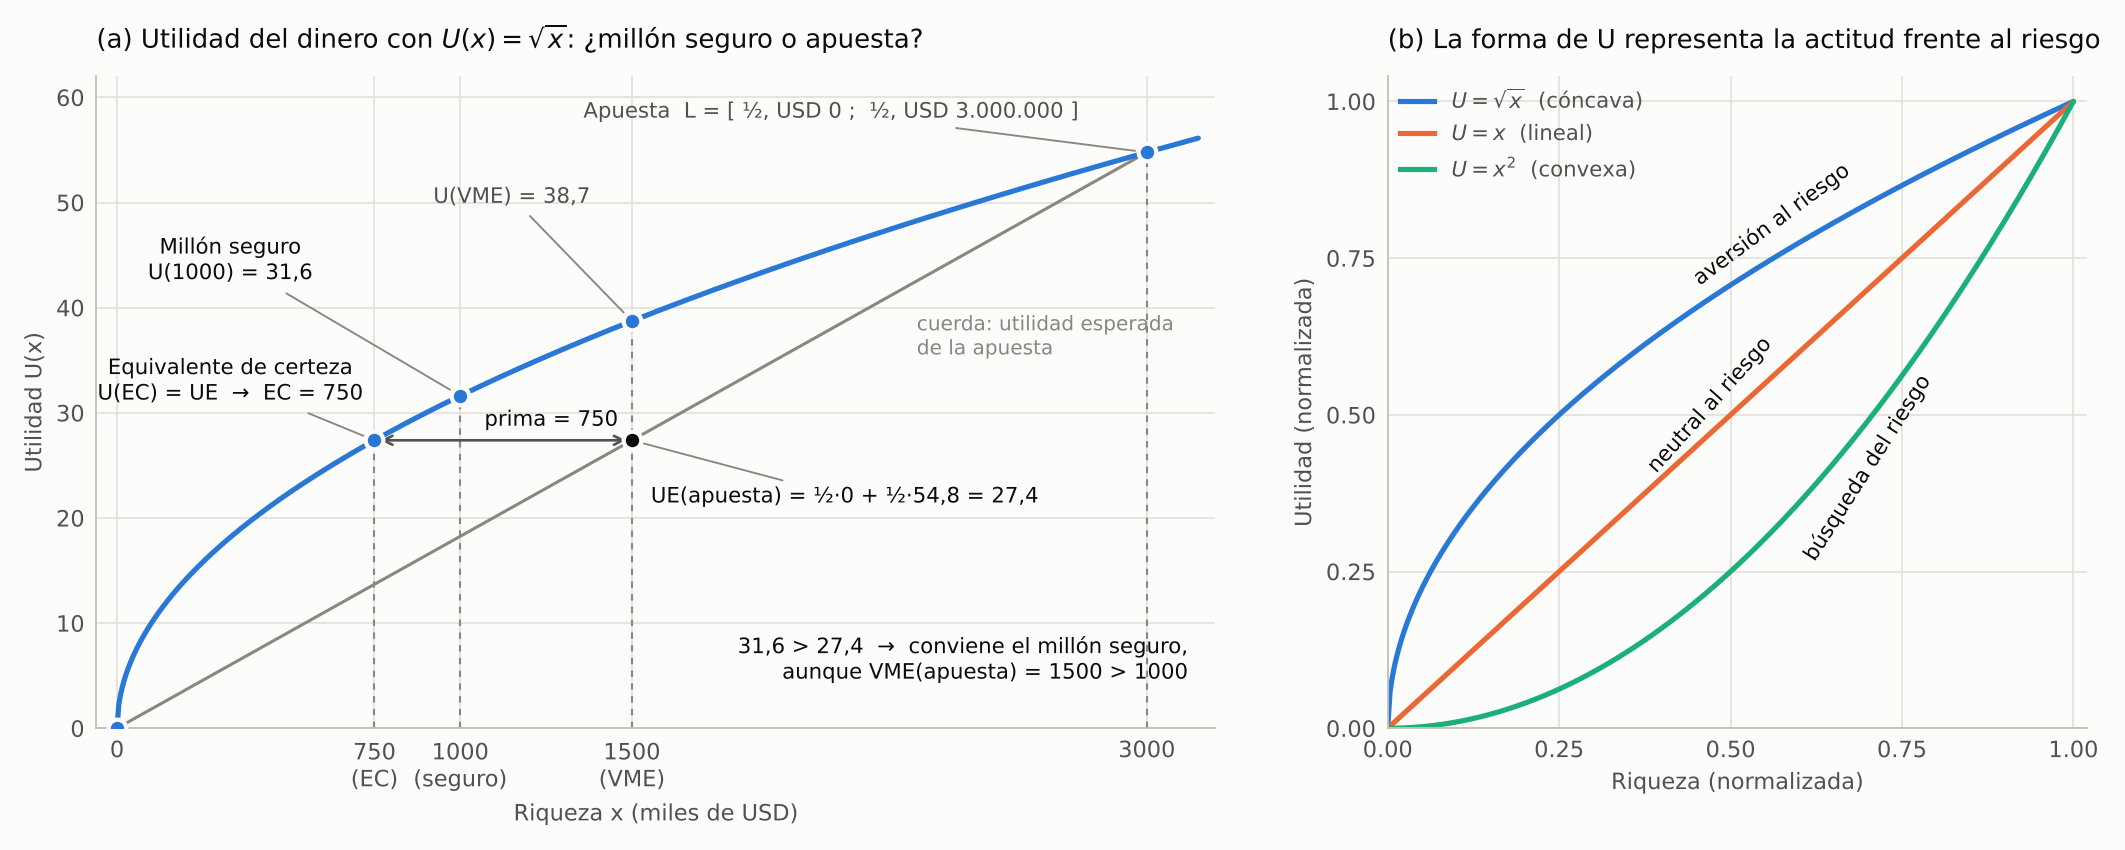
La **forma** de la curva de utilidad representa la **actitud del agente frente al riesgo**:

| Forma de $U$ | Actitud | Condición para una lotería $L$ |
|---|---|---|
| Cóncava | Aversión al riesgo | $U(L) < U(S_{\text{VME}(L)})$ |
| Lineal | Neutral al riesgo | $U(L) = U(S_{\text{VME}(L)})$ |
| Convexa | Búsqueda del riesgo | $U(L) > U(S_{\text{VME}(L)})$ |

Grayson (1960) midió empíricamente que la utilidad del dinero de las personas es aproximadamente proporcional a su logaritmo, como ya había propuesto Bernoulli (1738). Además, para montos chicos frente a la riqueza total cualquier curva es casi lineal; por eso, en decisiones con poco en juego, es razonable usar directamente el valor monetario esperado.

#### 7. Utilidad con varios atributos

En problemas reales un resultado se describe con varios atributos $\mathbf{x} = (x_1, \dots, x_n)$: para ubicar un aeropuerto importan el costo, el ruido y la siniestralidad; para un vehículo autónomo, el tiempo de viaje, la seguridad y el consumo. La función de utilidad $U(x_1, \dots, x_n)$ representa entonces **cuánto de un atributo está dispuesto a sacrificar el agente para ganar en otro**. Si los atributos son **mutuamente independientes en cuanto a preferencias**, se puede usar una **función de valor aditiva**:

$$V(x_1, \dots, x_n) = \sum_{i=1}^{n} V_i(x_i)$$

donde cada $V_i$ depende de un solo atributo. Bajo incertidumbre, si se cumple la independencia mutua de utilidad, la forma correspondiente es multiplicativa.

#### 8. Dónde aparece en IA

- **Agentes basados en utilidad (teoría de la decisión):** eligen la acción de mayor utilidad esperada (principio de MUE).
- **Decisiones secuenciales (procesos de decisión de Markov):** la utilidad de un estado es la suma esperada de recompensas descontadas que se obtienen a partir de él, $U^{\pi}(s) = E\left[\sum_{t=0}^{\infty} \gamma^{t} R(s_t) \mid \pi, s_0 = s\right]$; la iteración de valores calcula esa función.
- **Medicina y seguridad:** se usan escalas de utilidad como los AVAC (años de vida ajustados por calidad) y la micromortalidad (una probabilidad de muerte de 1 en un millón).
- **Sistemas expertos basados en la teoría de la decisión:** combinan la probabilidad de cada diagnóstico con la utilidad de cada resultado para recomendar la acción de mayor utilidad esperada.

#### 9. Aclaración: es un modelo normativo

La teoría de la utilidad describe cómo **debería** decidir un agente racional, no necesariamente cómo deciden las personas. Por ejemplo, en la paradoja de Allais la mayoría prefiere *100 % de ganar USD 3.000* antes que *80 % de ganar USD 4.000*, pero prefiere *20 % de ganar USD 4.000* antes que *25 % de ganar USD 3.000*. Con $U(0) = 0$, la primera elección implica $U(3000) > 0{,}8\,U(4000)$ y la segunda (multiplicando por 4) $0{,}8\,U(4000) > U(3000)$: ninguna función de utilidad puede explicar las dos elecciones. Para un agente artificial esto no es un problema, porque su función de utilidad la define el diseñador.

#### En síntesis

Una función de utilidad representa **qué quiere el agente y cuánto lo quiere**:

1. Ordena los estados según las preferencias del agente: $U(A) > U(B) \iff A \succ B$.
2. Combinada con las probabilidades, le permite elegir la mejor acción bajo incertidumbre: $A^{*} = \arg\max_{A} \text{UE}(A \mid E)$.
3. Su forma (cóncava, lineal o convexa) codifica la actitud frente al riesgo.
4. Con varios atributos, codifica los compromisos entre objetivos en conflicto.

Su existencia está garantizada por los axiomas de la teoría de la utilidad, y es la base del resto de los temas del práctico: la toma de decisiones basada en utilidad, el valor de la información y los sistemas expertos basados en la teoría de la decisión.

2. Respondan las siguientes preguntas. Cada respuesta corresponde a un axioma de la utilidad, indique cuál se relaciona con cada pregunta y dé una breve explicación de lo que dice el axioma.

&emsp;&emsp;2.1 ¿Qué color prefieren?

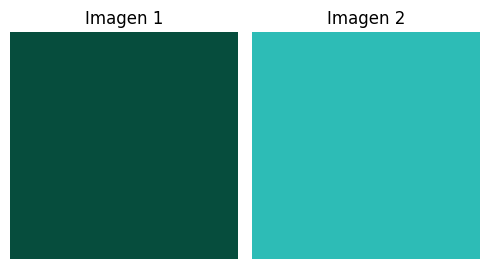

In [6]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URLs directas de Google Drive
url1 = "https://drive.google.com/uc?export=view&id=1aofwvS7bUVmKS6MlTcpL2ZgVa9JuGJex"
url2 = "https://drive.google.com/uc?export=view&id=1-htp7twx9y5-GpzMUXl9hk-X3kV-BVz6"

# Función para descargar y redimensionar imagen
def load_and_resize(url, size=(10, 10)):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = img.resize(size, Image.Resampling.LANCZOS)  # redimensionar a 150x150
    return img

# Cargar imágenes
img1 = load_and_resize(url1)
img2 = load_and_resize(url2)

# Crear figura con 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(5, 5))

# Mostrar primera imagen
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title("Color 1")

# Mostrar segunda imagen
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Color 2")

plt.tight_layout()
plt.show()

Axioma de Completitud o Totalidad. Establece que ante 2 alternativas el agente siempre puede compararlas y definir su postura. Dicho de otra manera, el agente siempre peude establecer una relación de preferencia entre ambos estados, ya sea la preferencia del color 1 por sobre el color 2 o viceversa.

&emsp;&emsp;2.2 Entre sacar un 10 o un 7 en un parcial, ¿qué prefieren? ¿Y entre el 7 y desaprobar?

Axioma de Transitividad. Establece la coherencia en el orden de preferencias, si se prefiere el 10 por sobre el 7, y el 7 por sobre desaprobar entonces obligatoriamente se prefiere el 10 por sobre desaprobar. La transitividad previene contradicciones lógicas en las elecciones del agente.


&emsp;&emsp;2.3 Imagínense que hacen una apuesta de $100 jugando al cara o cruz, si pudieran trucar la moneda para que ustedes ganaran un porcentaje *p* de las veces, ¿en qué valor configurarían *p*?

Axioma de Monotonicidad. Establece que si se prefiere un resultado A sobre otro resultado B, siempre el agente va a preferir estrictamente aquella opcion que le da mayor probabilidad al resultado preferido A.
En el caso específico de la pregunta, el agente va a preferir ganar a perder por lo que va a configurar la probabilidad p al máximo posible.


&emsp;&emsp;2.4 En una feria hay dos juegos: uno en el que el premio son $100 y otro en el que el premio es una piedra, ambos con una probabilidad *p* de ganar al juego. ¿A qué juego prefieren jugar?

Axioma de Sustituibilidad. Establece que si un agente prefiere un resultado (la plata por sobre la piedra) entonces hay una preferencia estricta del juego que ofrece el resultado buscado por sobre la que no lo ofrece.


&emsp;&emsp;2.5 En un casino hay dos juegos y en ambos el premio son $1000. El primer juego se gana cuando se tira una moneda y sale cara y el segundo juego se gana cuando sale 6 en un dado. ¿A qué juego prefieren jugar?

Axioma de Monotonicidad. Establece que si se prefiere un resultado A sobre otro resultado B, siempre el agente va a preferir estrictamente aquella opcion que le da mayor probabilidad al resultado preferido A.
En este caso la moneda ofrece un 50% de probabilidad de ganar mientras que el dado ofrece solo 16.7% por lo que el agente siempre va a elegir el juego de la moneda.


&emsp;&emsp;2.6 Supongamos que quiere postularse a una beca. Primero, existe un 60% de probabilidad de que le llamen para una entrevista. Si no le llaman, entonces hay un 20% de probabilidad de que le ofrezcan participar en un curso online ¿Cuál es la probabilidad total de cada evento (recibir la beca, recibir el curso o no recibir nada)?

Axioma de Descomponibilidad. Establece que una lotería secuencial en varias etapas es equivalente a una loteria simple.
-Probabilidad de recibir la beca: P(B)=0.6
-Probabilidad de NO ser llamado para la entrevista: P(NE)=1-0.6=0.4
-Probabilidad de recibir curso online: P(C)=P(NE) * 0.2=0.4 * 0.2=0.08
-Probabilidad de NO recibir nada(probabilidad de que no hagan la entrevista y que no den el curso): P(N)=P(NE) * P(NC)=P(NE) * (1-0.2)=0.4 * 0.8=0.32

3. Los boletos de una lotería cuestan un dólar. Hay dos juegos posibles con distintos premios: uno de 10 dólares con una probabilidad de uno entre 50 y otro de 1.000.000 dólares con una probabilidad de uno entre 2.000.000.

&emsp;&emsp;3.1 ¿Cuál es el valor monetario esperado del boleto de lotería?


&emsp;&emsp;3.2 ¿Cuándo es razonable comprar un boleto?

4. Hay que reparar una máquina averiada y el mecánico diagnostica que si la avería es leve la reparación costará \$300, pero si es grave costará \$1.200. La probabilidad de que la avería sea grave es 2/3. También se ofrece la alternativa de comprar una máquina
usada por \$600. Qué decisión se tomará si:

&emsp;&emsp;4.1 La función de utilidad fuese la mostrada por el agente rojo.

&emsp;&emsp;4.2 La función de utilidad fuese la mostrada por el agente verde.

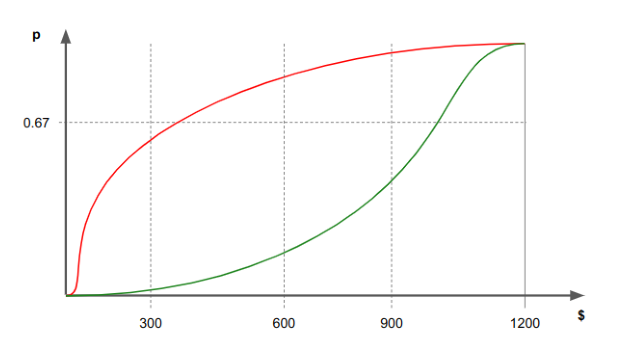

In [7]:
url = "https://drive.google.com/uc?export=view&id=1vNTlLArEhsxTOIvgs-NJ7NcE0B0JPJcw"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar con figura más grande
plt.figure(figsize=(img.width / 80, img.height / 80))  # ajustá el divisor según densidad deseada
plt.imshow(img)
plt.axis('off')
plt.show()

- Si La función de utilidad fuese la mostrada por el agente rojo, el agente preferiría hacer la reparación

    - Como el precio de la "maquina usada" sería 600, el agente rojo estaría dispuesto a realizar la reparación con una probabilidad de que la reparación sea grave mas grande que la planteada de 0,67 (aparenta ser 0,8 el umbral donde no acepta la reparación)

    - Este agente, para la misma probabilidad de 0,67, siempre preferiría realizar la reparación mientras que el precio de la usada sea mayor a algún valor superior a 350


- Si La función de utilidad fuese la mostrada por el agente Verde, el agente preferiría comprar la maquina usada

    - Como el precio de la "maquina usada" sería 600, el agente verde estaría dispuesto a realizar la reparación sólo si la probabilidad de que la reparación sea grave fuera mas chica que la planteada (aparenta ser 0,3 el umbral)

    - Este agente, para la misma probabilidad de 0,67, siempre preferiría realizar la reparación mientras que el precio de la usada sea mayor a algún valor superior a 1000

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

5. En unos laboratorios de un hospital se está investigando sobre una sustancia para la curación de una determinada enfermedad. Dicha sustancia ha sido inyectada en varias cobayas enfermas para verificar sus efectos. Los resultados de las pruebas realizadas se sintetizan en la siguiente tabla:

<table><tr><td><b>Estado de la enfermedad</td><td><b>Concentración de la sustancia</td><td><b>Número de dosis</td><td><b>Condición física</td><td><b>Efecto</td></tr>

<tr><td>Incipiente</td><td>75</td><td>70</td><td>Fuerte</td><td>Curación</td></tr>

<tr><td>Incipiente</td><td>80</td><td>90</td><td>Fuerte</td><td>Defunción</td></tr>

<tr><td>Incipiente</td><td>85</td><td>85</td><td>Débil</td><td>Defunción</td></tr>

<tr><td>Incipiente</td><td>62</td><td>95</td><td>Débil</td><td>Defunción</td></tr>

<tr><td>Incipiente</td><td>79</td><td>70</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>72</td><td>90</td><td>Fuerte</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>83</td><td>78</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>64</td><td>66</td><td>Fuerte</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>81</td><td>75</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Terminal</td><td>71</td><td>80</td><td>Fuerte</td><td>Defunción</td></tr>

<tr><td>Terminal</td><td>65</td><td>70</td><td>Fuerte</td><td>Defunción</td></tr>

<tr><td>Terminal</td><td>75</td><td>80</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Terminal</td><td>68</td><td>80</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Terminal</td><td>70</td><td>96</td><td>Débil</td><td>Curación</td></tr></table>

Determine las reglas que rigen las condiciones en las que se ha de administrar una sustancia e implemente un sistema experto en CLIPS que determine si un sujeto resultará curado o no.


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)